# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Saffira Arentsen
* Username: sarentsen
* Student number: s6239145
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

Filename: ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     206   (100, 100, 101)   int16 (rescales to float32)   
(50, 100, 100)


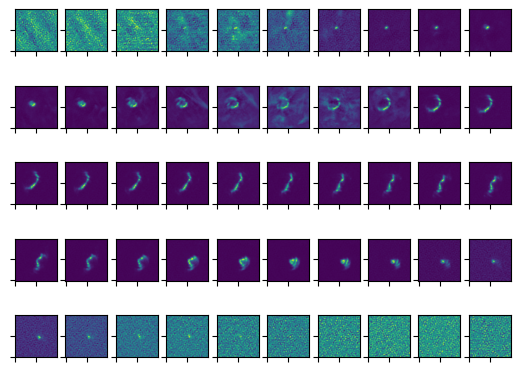

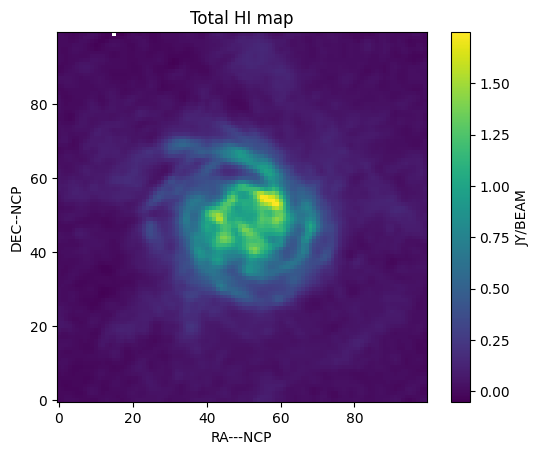

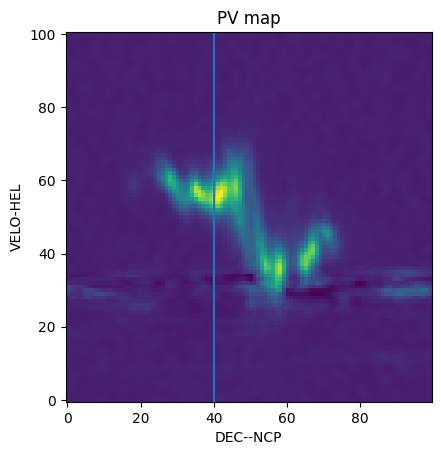

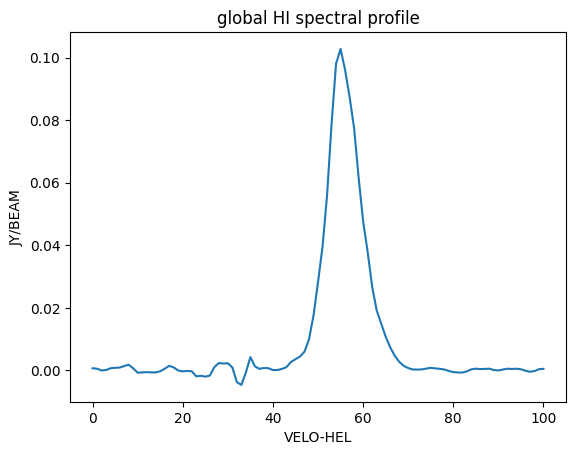

The plotted profile is the profile where the declination is equal to 40, so that is at the vertical line in the PV map


In [2]:
from matplotlib.pyplot import figure, show
import numpy as np
from astropy.io import fits

hdulist = fits.open('ngc6946.fits')
hdulist.info()
hdr = hdulist[0].header
data = np.asarray(hdulist[0].data)
zindices = np.arange(1, 101, 2)

print(data[zindices].shape)

fig = figure()
x=1

# create 5 x 10 mosaic with channel maps
for i in range(1, 101, 2):
    frame = fig.add_subplot(5, 10, x)
    frame.imshow(data[i], origin='lower')
    frame.set_xticklabels([])
    frame.set_yticklabels([])
    x+=1
show()

# create total HI map 
total_map = np.sum(data[21:79], axis=0) # suitable range?

fig = figure()
frame1 = fig.add_subplot(1, 1, 1)
frame1.set_title('Total HI map')
frame1.set_xlabel(hdr['CTYPE1'])
frame1.set_ylabel(hdr['CTYPE2'])
im = frame1.imshow(total_map, origin='lower')
fig.colorbar(im, ax=frame1, label=hdr['BUNIT'])
show()

# position velocity map
pvmap = data[:, :, 50]
fig = figure()
frame2 = fig.add_subplot(1, 1, 1)
frame2.set_title('PV map')
frame2.imshow(pvmap, origin='lower')
frame2.set_xlabel(hdr['CTYPE2'])
frame2.set_ylabel(hdr['CTYPE3'])
frame2.axvline(40)
show()

# global HI spectral profile
profile = data[:, 40, 50]
fig = figure()
frame2 = fig.add_subplot(1, 1, 1)
frame2.set_title('global HI spectral profile')
frame2.plot(profile)
frame2.set_xlabel(hdr['CTYPE3'])
frame2.set_ylabel(hdr['BUNIT'])
show()

print('The plotted profile is the profile where the declination is equal to 40, so that is at the vertical line in the PV map')

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

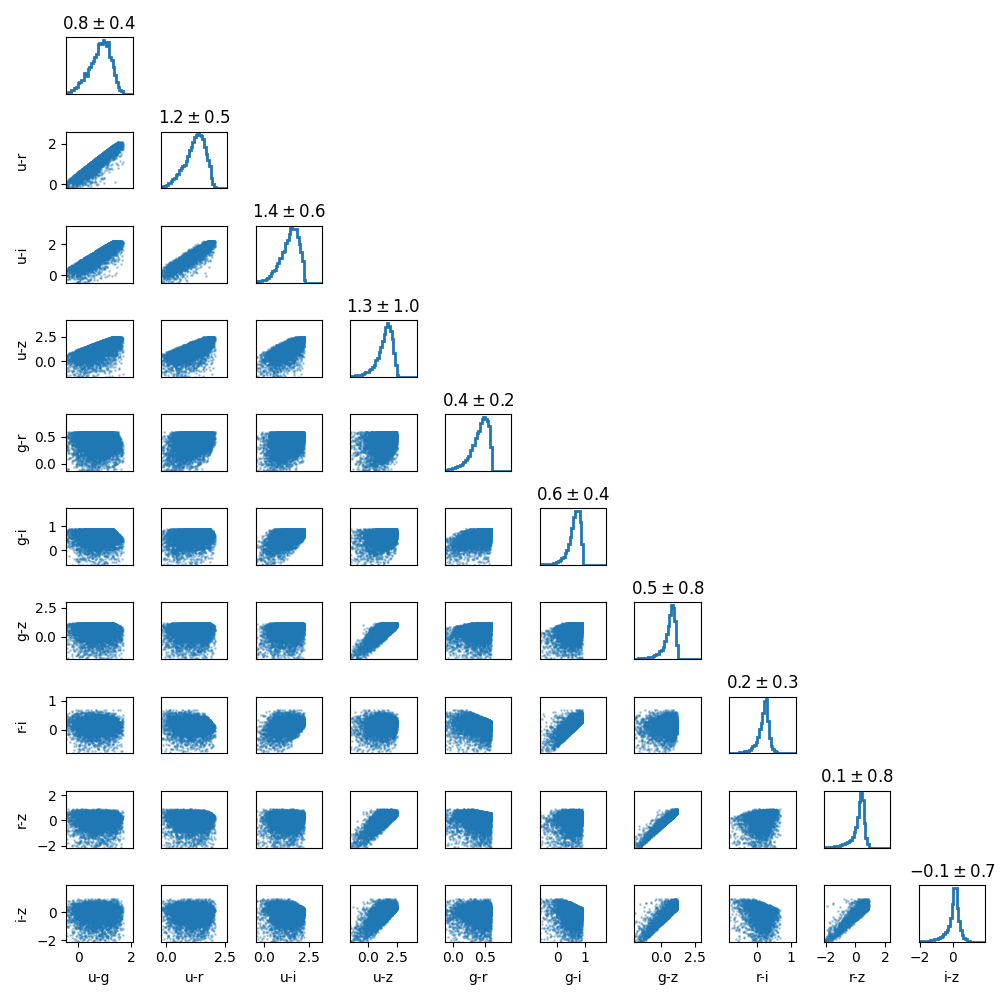
   
**Plot and answer**:

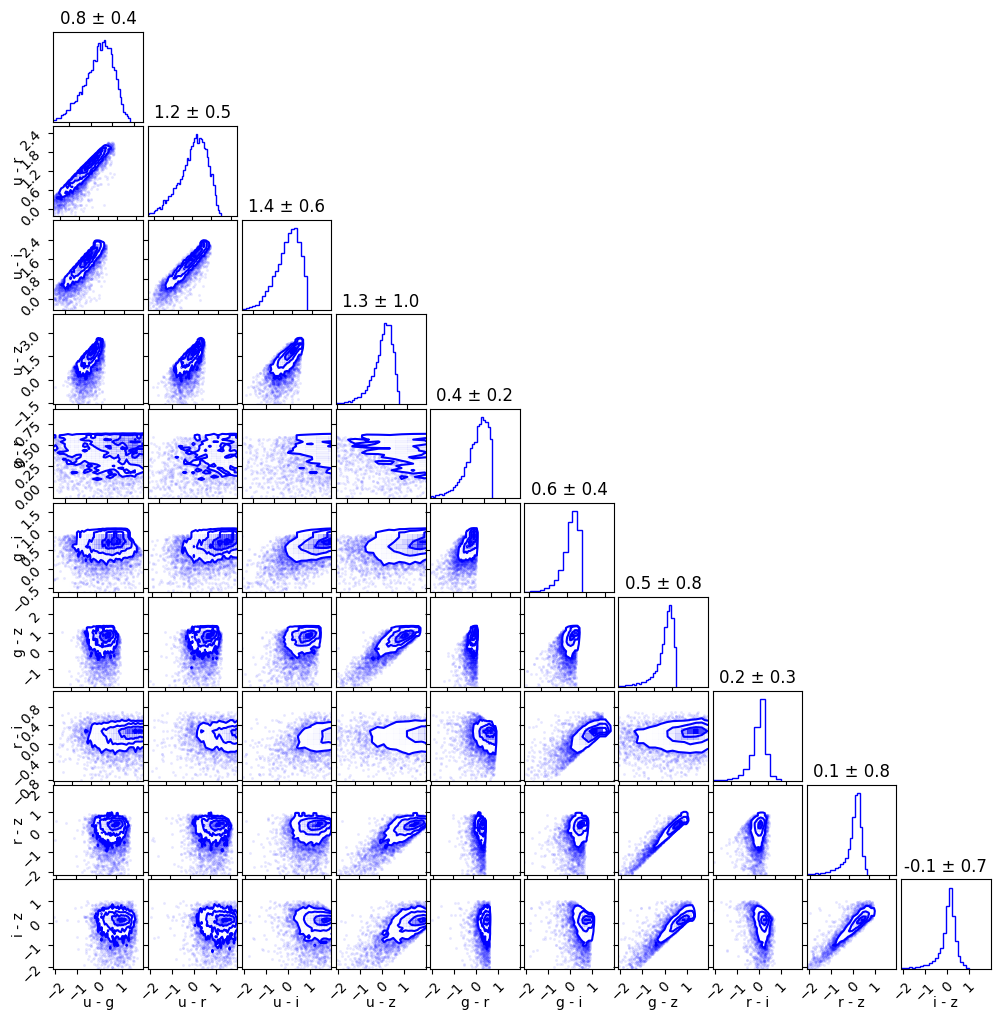

I give up :(


In [4]:
import numpy as np
from matplotlib.pyplot import figure, show
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import corner

hdulist = fits.open('SDSS_DR17_galaxies.fits')
table = Table(hdulist[1].data)
df = table.to_pandas()
df = df[df>=0]

colors = ['u', 'g', 'r', 'i', 'z']
color_cols = []
for i in range(len(colors)):
    for j in range(i+1, len(colors)):
        diff_name = f'{colors[i]} - {colors[j]}'
        diff = df[colors[i]] - df[colors[j]]
        df[diff_name] = diff
        color_cols.append(diff_name)

data = df[color_cols]

means, stds, titles = [], [], []
for col in color_cols:
    mean = np.mean(data[col])
    std = np.std(data[col])
    means.append(mean)
    stds.append(std)
    titles.append(f'{mean:.1f} ± {std:.1f}')

fig = figure(figsize=(10, 10))
figure = corner.corner(data, bins=100, fig=fig, labels=color_cols, color='b')

frames = np.array(figure.axes).reshape((10, 10))

for i in range(10):
    frame = frames[i, i]
    frame.set_title(titles[i])
    mean = means[i]
    std = stds[i]
    frame.set_xlim(mean - 3*std, mean + 3*std)
    for j in range(10):
        if i != j:
            frame = frames[i, j]
            frame.set_xlim(mean - 3*std, mean + 3*std)
            frame.set_ylim(mean - 3*std, mean + 3*std)
show()

print("I give up :(")

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

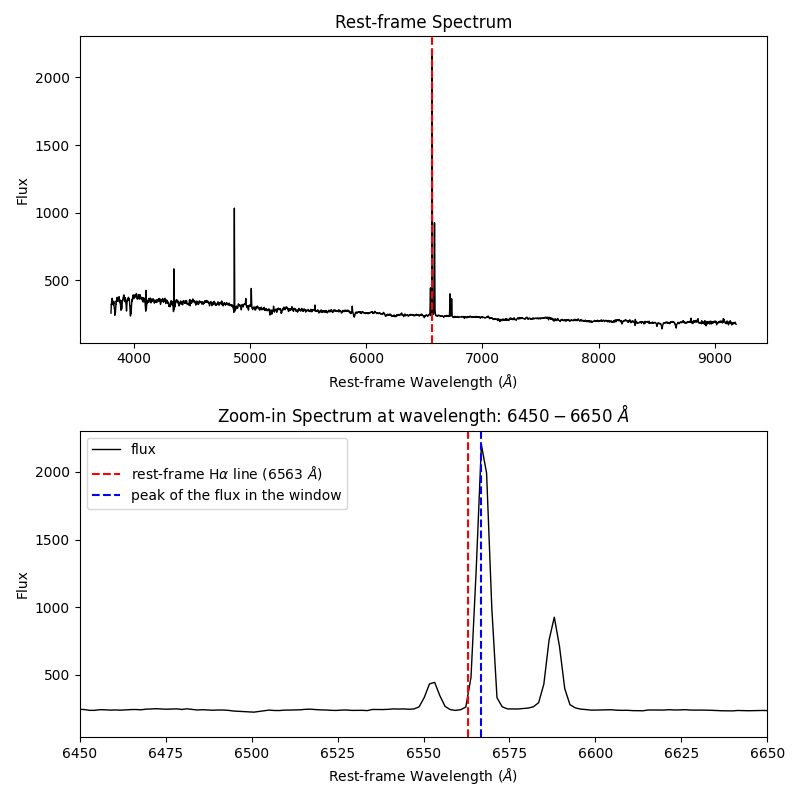

In [ ]:
from astropy import coordinates as coords
from astropy.constants import c
import astropy.units as u
from astroquery.sdss import SDSS
from matplotlib.pyplot import figure, show
import numpy as np

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
sp = SDSS.get_spectra(matches=xid)
# apparently only 1 item in the lists of hdulist objects
hdulist = sp[0]
data = hdulist[1].data

flux = data['flux']
loglam = data['loglam']
wavelength = 10 ** loglam

# z + 1 = wavelength_obs / wavelength_rest 
# wavelength_rest = wavelength_obs / (z+1)
rest_wave = wavelength / 1.0038
peak = flux.max()
peak_index = np.where(flux==peak)[0]
print(peak_index)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(rest_wave, flux, color='black')
frame.axvline(6563, linestyle='--', color='red')
frame.set_xlabel(r'Rest-frame wavelength $(\AA)$')
frame.set_ylabel('Flux')

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(rest_wave, flux, label='flux', color='black')
frame.set_xlabel(r'Rest-frame wavelength $(\AA)$')
frame.set_ylabel('Flux')
frame.set_xlim(6450, 6650)
frame.axvline(rest_wave[peak_index], linestyle='--', color='blue', label=rf'peak of the flux in the window (at {rest_wave[peak_index]} $\AA$)')
frame.axvline(6563, linestyle='--', color='red', label=r'rest-frame of H$\alpha$ (6563 $\AA$)')
frame.legend()
show()

v = c * (rest_wave[peak_index]-6563) /6563
print(v.to(u.km/u.s))


/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

The offset between the two wavelenghts might have been caused by a systematic error in the equipment used that measured the wavelengths.
Also the redshift formula doesn't account for peculiar velocities, so this could have caused the offset.

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [ ]:
from astropy.io import fits
from astropy.visualization import ImageNormalize, SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
from matplotlib.pyplot import figure, show

hdulist = fits.open('20210422_Li_.00000066.FIT')
hdulist.info()
image_data = hdulist[0].data
if 'int' in str(image_data.dtype):
    image_data = image_data.astype('float')
print("\n ===> Number type:", image_data.dtype)

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    ''' Returns an image object from ax.imshow with applied scaling/stretching from 'scale'.
    data: the image array that is used
    ax: matplotlib axes that is plotted on'''
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

fig = figure(figsize=(12, 12))
scales = ['none', 'linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']
i = 1
for scale in scales:
    frame = fig.add_subplot(4, 2, i)
    frame.set_title(f'Used scale: {scale}')
    if scale=='none': frame.imshow(image_data, interpolation='none', origin='lower', cmap='gray')
    else: imdisplay(image_data, frame, scale=scale)
    i += 1
fig.tight_layout()
show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show
from pathlib import Path
import astroalign as aa
from math import ceil

excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are part of the file name

path = Path('data')
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

fig = figure(figsize=(8,6), tight_layout=True)

images = []
for filepath in filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()

datacube = np.stack(images)
stacked_images = np.median(datacube, axis=0)

frame = fig.add_subplot(1, 1, 1)
imdisplay(stacked_images, frame, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

# plot all
fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()

# Now align images first
ref_image = images[0]
aligned_ims = []
for im in images:
    try:
        # I only used 50 max_control_points because otherwise this takes too long to run
        aligned_im, footprint = aa.register(im, ref_image, detection_sigma=10.0, max_control_points=50, min_area=5)
        aligned_ims.append(aligned_im)
        print('succesful')
    except:
        print('Failed')

fig = figure(figsize=(8,6), tight_layout=True)
datacube = np.stack(aligned_ims)
stacked_images = np.median(datacube, axis=0)
frame = fig.add_subplot(1, 1, 1)
imdisplay(stacked_images, frame, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")